In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [35]:
ORGANS = ['heart']
OUTPUT_DIR = 'output'

In [48]:
def plot_base_res(organ, assay, metric='avg', save_plot=False):
    df = pd.read_csv(f'{OUTPUT_DIR}/{organ}_{assay}_base_res.csv')
    df = df.sort_values(f'avg_diff_{metric}', ascending=False).reset_index(drop=True)
    cell_type_df = pd.read_csv(f'data/metadata/{organ}_{assay}_cell_type_map.csv')
    cell_map = dict(zip(
        cell_type_df['cell_ontology_id'],
        cell_type_df['cell_ontology_class']
    ))
    df['cell_type_name'] = df['cell_type'].map(cell_map)
    fig, ax = plt.subplots(figsize=(max(10, len(df) * 0.5), 6))
    for i, row in df.iterrows():
        color = '#2196F3' if row['cl_ontology_used'] else '#FF7043'        
        ax.errorbar(
            i,
            row[f'avg_diff_{metric}'],
            yerr=row[f'std_diff_{metric}'],
            fmt='o',
            color=color,
            capsize=4,
            markersize=6
        )
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df['cell_type_name'], rotation=45, ha='right', fontsize=8)
    ax.set_xlabel('Cell Type')
    ax.set_ylabel('Mean Absolute Difference')
    ax.set_title(f'Mean and StdDev Error between AlphaGenome Predictions and Ground Truth for {organ.capitalize()} scRNA-seq Expression')
    ax.scatter([], [], color='#2196F3', label='Conditioned on cell type')
    ax.scatter([], [], color='#FF7043', label='Conditioned on organ')
    ax.legend()
    plt.tight_layout()
    plt.show()
    if save_plot: plt.savefig(f'{OUTPUT_DIR}/{organ}_{assay}_abs_diff_plot.png')

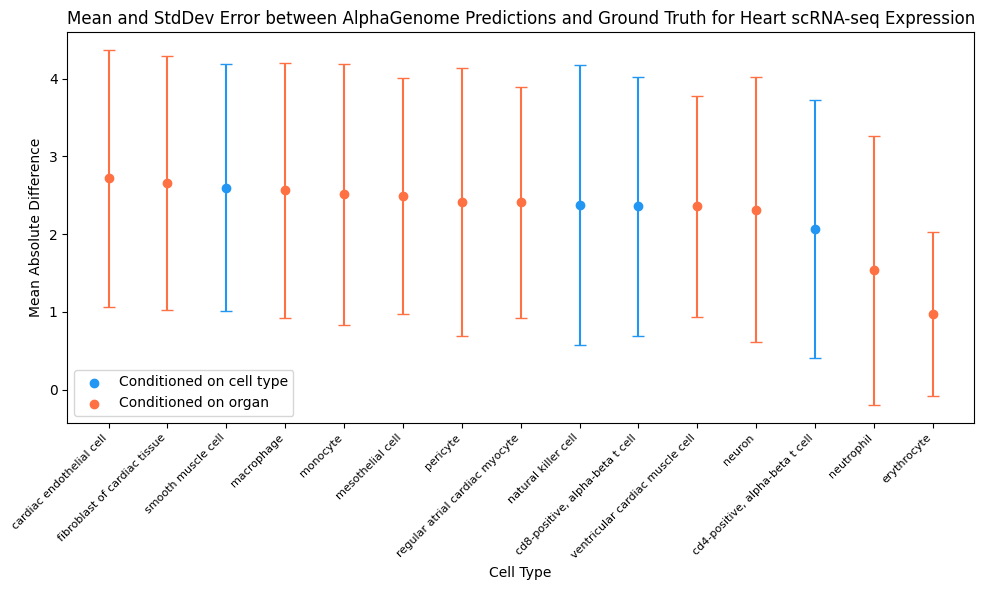

In [49]:
for organ in ORGANS:
    plot_base_res(organ, '10X', metric='avg')